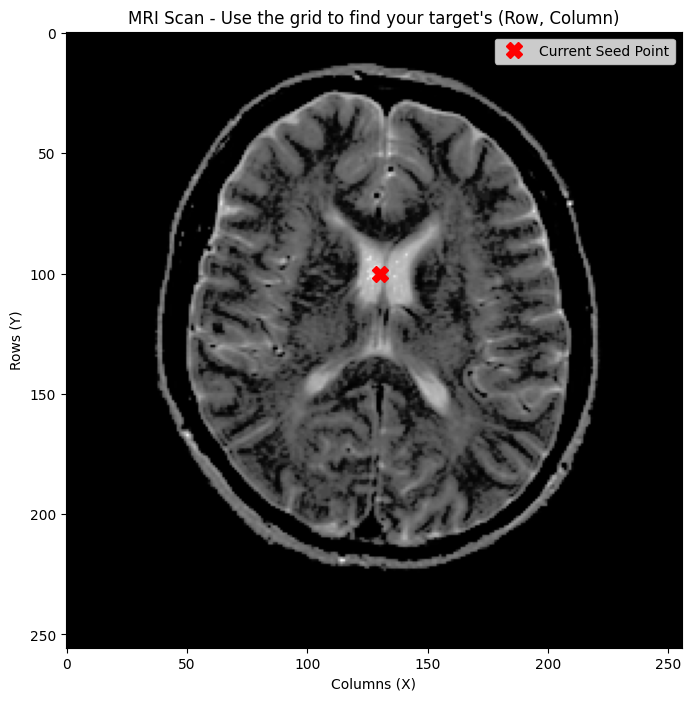

In [13]:
# Cell 1: Setup, Load MRI, and Seed Selection
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. Load your specific MRI image in grayscale
image_path = "mri.png" 
img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

if img is None:
    raise ValueError(f"Could not find {image_path}. Please ensure it is in the same folder as this notebook.")

# --- IMPORTANT: UPDATE THIS SEED POINT ---
# Look at the axes of the plotted image below to find the (row, column) 
# or (y, x) coordinates of the structure you want to segment.
seed_point = (100, 130)  # Change these numbers based on the plot!

# Display the MRI with axes so you can pick the perfect seed point
plt.figure(figsize=(8, 8))
plt.imshow(img, cmap='gray')
plt.plot(seed_point[1], seed_point[0], 'rX', markersize=12, label='Current Seed Point')
plt.title("MRI Scan - Use the grid to find your target's (Row, Column)")
plt.xlabel("Columns (X)")
plt.ylabel("Rows (Y)")
plt.legend()
# Note: We are keeping the axes ON specifically to help you find coordinates
plt.show()

# Convert to float32 early for the upcoming feature map math
img_float = img.astype(np.float32)

In [14]:
# Cell 2: Define the Region Growing Algorithms

def static_rg(image, seed, threshold):
    """Grows a region by comparing every pixel to the INITIAL seed intensity."""
    rows, cols = image.shape
    segmented = np.zeros((rows, cols), dtype=np.uint8)
    visited = np.zeros((rows, cols), dtype=bool)
    
    seed_val = float(image[seed[0], seed[1]])
    points = [seed]
    visited[seed[0], seed[1]] = True
    neighbors = [(-1, 0), (1, 0), (0, -1), (0, 1), (-1, -1), (-1, 1), (1, -1), (1, 1)]
    
    while points:
        cx, cy = points.pop(0)
        segmented[cx, cy] = 255
        for dx, dy in neighbors:
            nx, ny = cx + dx, cy + dy
            if 0 <= nx < rows and 0 <= ny < cols and not visited[nx, ny]:
                visited[nx, ny] = True
                if abs(float(image[nx, ny]) - seed_val) <= threshold:
                    points.append((nx, ny))
    return segmented

def dynamic_rg(image, seed, threshold):
    """Grows a region by comparing pixels to the RECOMPUTED AVERAGE intensity."""
    rows, cols = image.shape
    segmented = np.zeros((rows, cols), dtype=np.uint8)
    visited = np.zeros((rows, cols), dtype=bool)
    
    region_sum = float(image[seed[0], seed[1]])
    region_count = 1
    region_mean = region_sum
    
    points = [seed]
    visited[seed[0], seed[1]] = True
    neighbors = [(-1, 0), (1, 0), (0, -1), (0, 1), (-1, -1), (-1, 1), (1, -1), (1, 1)]
    
    while points:
        cx, cy = points.pop(0)
        segmented[cx, cy] = 255
        for dx, dy in neighbors:
            nx, ny = cx + dx, cy + dy
            if 0 <= nx < rows and 0 <= ny < cols and not visited[nx, ny]:
                visited[nx, ny] = True
                pixel_val = float(image[nx, ny])
                if abs(pixel_val - region_mean) <= threshold:
                    points.append((nx, ny))
                    region_sum += pixel_val
                    region_count += 1
                    region_mean = region_sum / region_count
    return segmented

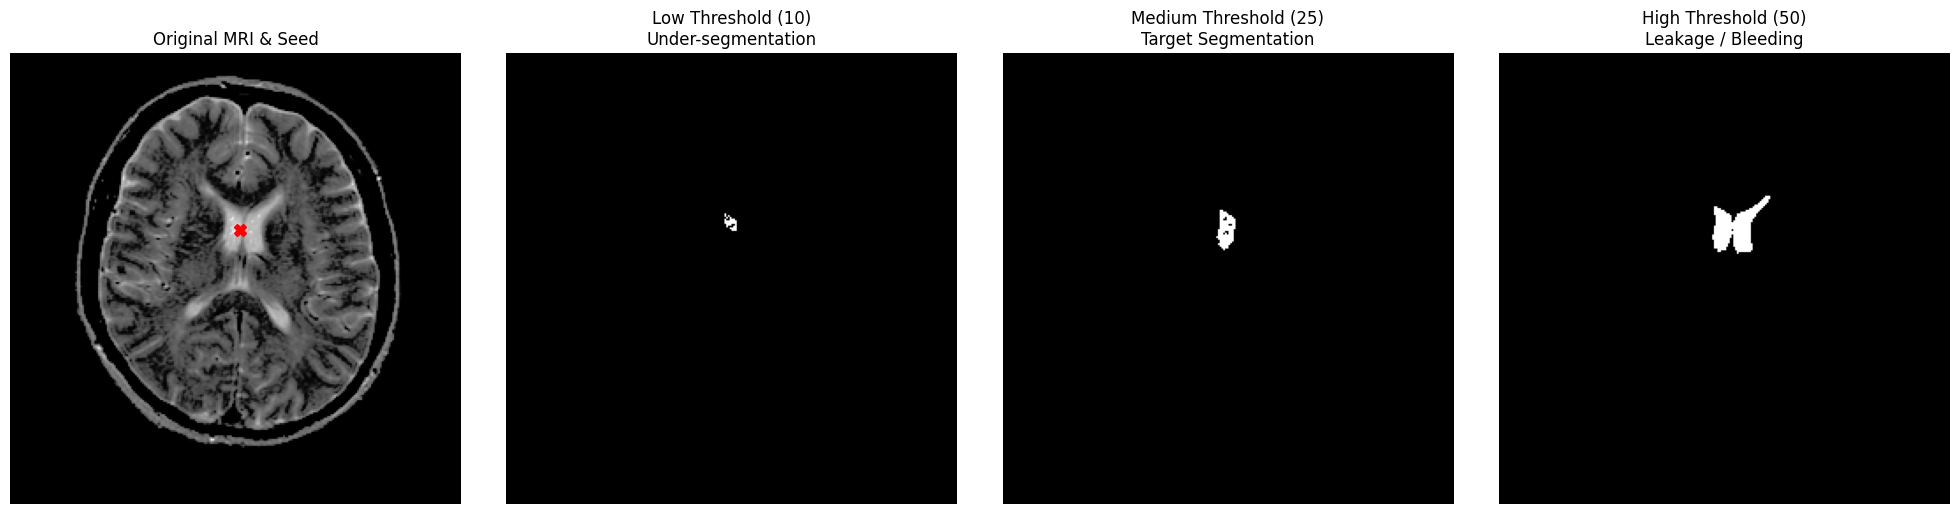

In [15]:
# Cell 3: Testing Thresholds and Leakage on MRI Intensity

# NOTE: You may need to tune these thresholds based on your specific MRI's contrast!
thresh_low = 10   # Likely to under-segment
thresh_med = 25   # Goal: Target structure
thresh_high = 50  # Likely to leak into surrounding tissue

seg_low = static_rg(img, seed_point, thresh_low)
seg_med = static_rg(img, seed_point, thresh_med)
seg_high = static_rg(img, seed_point, thresh_high)

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

axes[0].imshow(img, cmap='gray')
axes[0].plot(seed_point[1], seed_point[0], 'rX', markersize=8)
axes[0].set_title("Original MRI & Seed")

axes[1].imshow(seg_low, cmap='gray')
axes[1].set_title(f"Low Threshold ({thresh_low})\nUnder-segmentation")

axes[2].imshow(seg_med, cmap='gray')
axes[2].set_title(f"Medium Threshold ({thresh_med})\nTarget Segmentation")

axes[3].imshow(seg_high, cmap='gray')
axes[3].set_title(f"High Threshold ({thresh_high})\nLeakage / Bleeding")

for ax in axes:
    ax.axis('off')

plt.tight_layout()
plt.show()

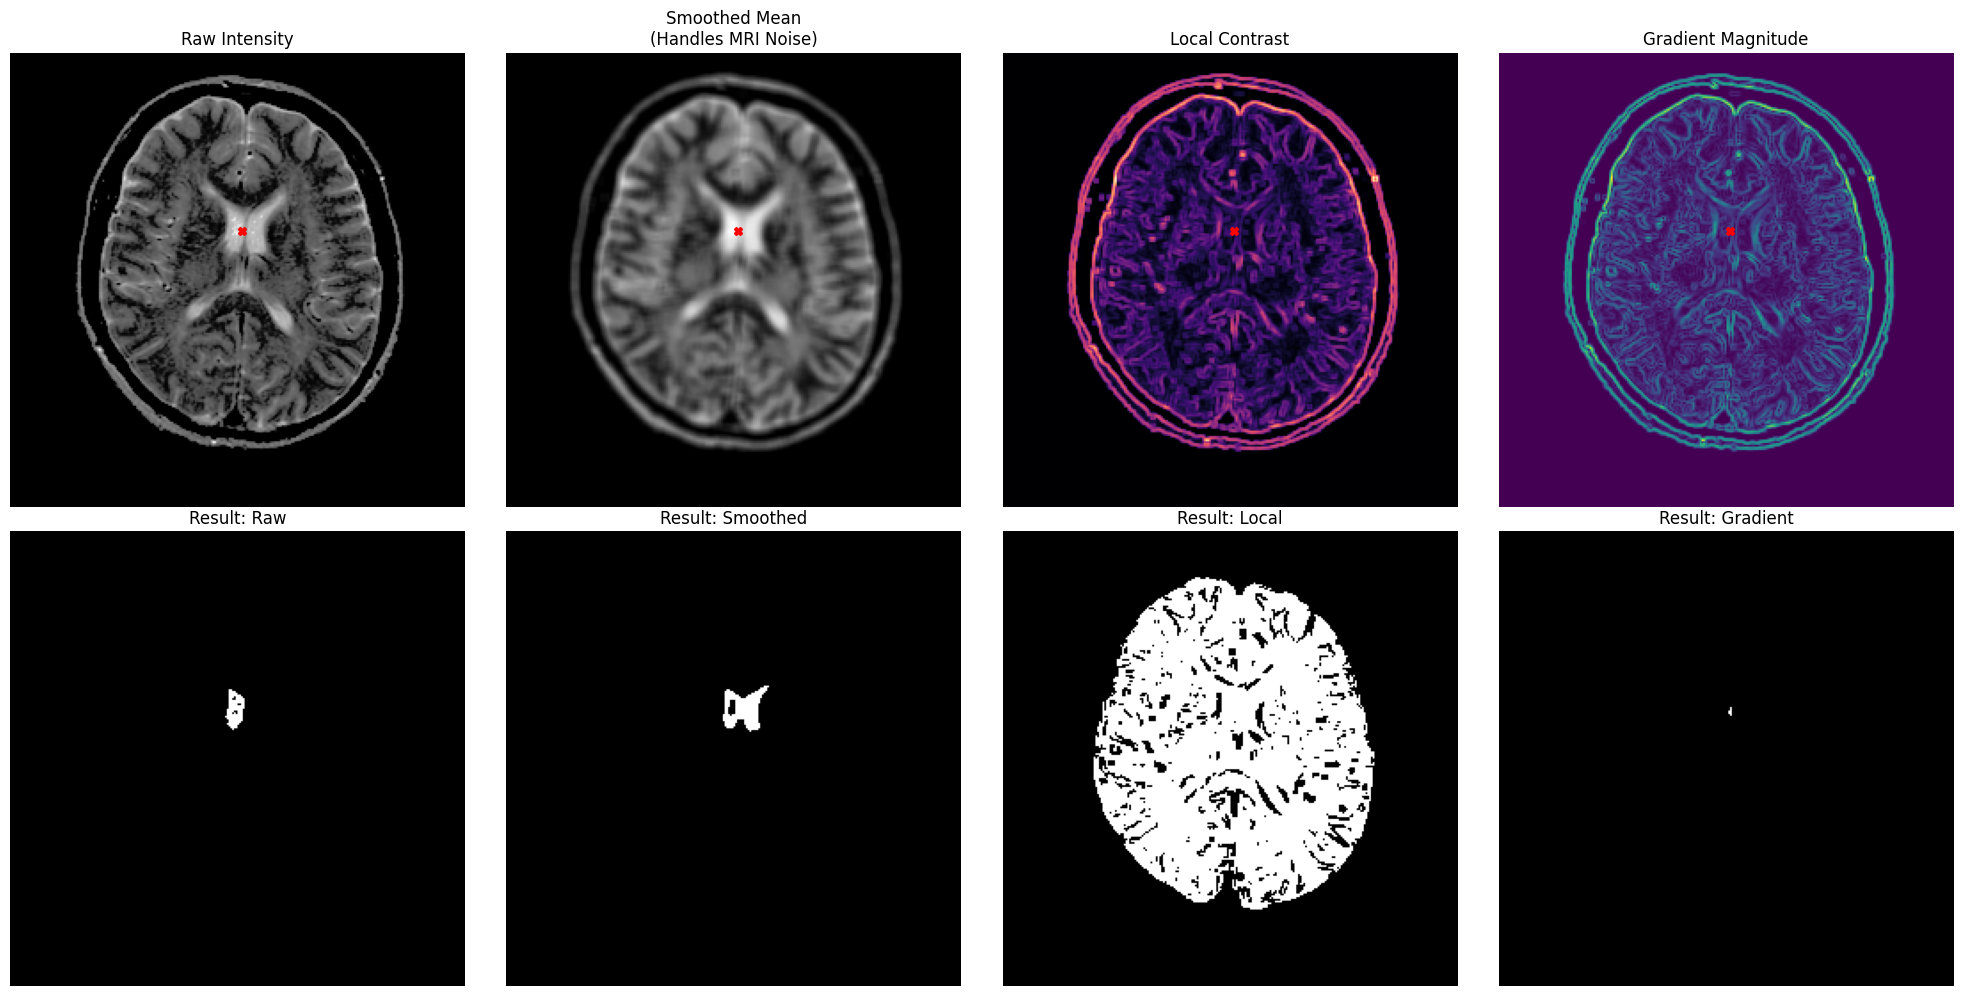

In [16]:
# Cell 4: Extracting and Using Feature Maps on the MRI

# 1. Generate the feature maps
mean_map = cv2.blur(img_float, (5, 5))

sq_img = cv2.blur(img_float**2, (3, 3))
mean_img_3 = cv2.blur(img_float, (3, 3))
contrast_map = np.sqrt(np.maximum(sq_img - mean_img_3**2, 0))

sobelx = cv2.Sobel(img_float, cv2.CV_64F, 1, 0, ksize=3)
sobely = cv2.Sobel(img_float, cv2.CV_64F, 0, 1, ksize=3)
gradient_map = np.sqrt(sobelx**2 + sobely**2)

# 2. Run segmentations (Thresholds adjusted for typical MRI feature scales)
# You may need to tweak these numbers for perfect results on your specific image
seg_intensity_fm = static_rg(img_float, seed_point, 25)
seg_mean_fm      = static_rg(mean_map, seed_point, 20)
seg_contrast_fm  = static_rg(contrast_map, seed_point, 15)
seg_gradient_fm  = static_rg(gradient_map, seed_point, 20)

# 3. Visualization
fig, axes = plt.subplots(2, 4, figsize=(20, 10))

maps = [img_float, mean_map, contrast_map, gradient_map]
results = [seg_intensity_fm, seg_mean_fm, seg_contrast_fm, seg_gradient_fm]
titles = ["Raw Intensity", "Smoothed Mean\n(Handles MRI Noise)", "Local Contrast", "Gradient Magnitude"]
cmaps = ['gray', 'gray', 'magma', 'viridis']

for i in range(4):
    axes[0, i].imshow(maps[i], cmap=cmaps[i])
    axes[0, i].set_title(titles[i])
    axes[0, i].plot(seed_point[1], seed_point[0], 'rX', markersize=6)
    axes[0, i].axis('off')
    
    axes[1, i].imshow(results[i], cmap='gray')
    axes[1, i].set_title(f"Result: {titles[i].split()[0]}")
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()

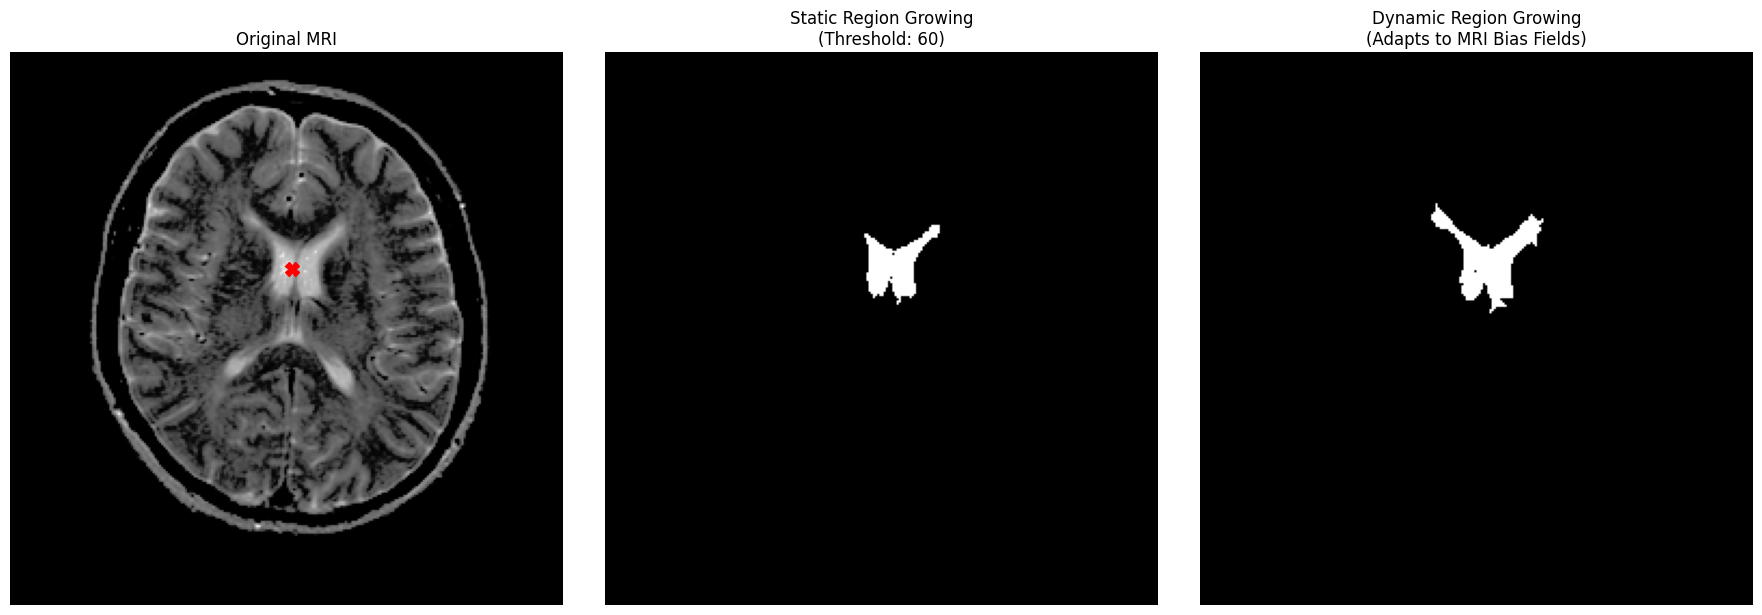

Pixels segmented by Static Method:  572
Pixels segmented by Dynamic Method: 857


In [28]:
# Cell 5: Static (Fixed Seed) vs. Dynamic (Recomputed Average) on MRI

# We use the same threshold for a fair comparison.
# Often, medical images have lighting biases (e.g., MRI bias field/RF inhomogeneity)
# where one side of the brain looks slightly brighter than the other.
comparison_threshold = 60

# Run algorithms
mri_static_res = static_rg(img, seed_point, comparison_threshold)
mri_dynamic_res = dynamic_rg(img, seed_point, comparison_threshold)

# Visualize
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(img, cmap='gray')
axes[0].plot(seed_point[1], seed_point[0], 'rX', markersize=10)
axes[0].set_title("Original MRI")
axes[0].axis('off')

axes[1].imshow(mri_static_res, cmap='gray')
axes[1].set_title(f"Static Region Growing\n(Threshold: {comparison_threshold})")
axes[1].axis('off')

axes[2].imshow(mri_dynamic_res, cmap='gray')
axes[2].set_title(f"Dynamic Region Growing\n(Adapts to MRI Bias Fields)")
axes[2].axis('off')

plt.tight_layout()
plt.show()

print(f"Pixels segmented by Static Method:  {np.sum(mri_static_res == 255)}")
print(f"Pixels segmented by Dynamic Method: {np.sum(mri_dynamic_res == 255)}")